# 2단계: MNIST 손글씨 숫자 분류 CNN

딥러닝 실습의 전체 사이클을 경험합니다:

**데이터 준비 → 모델 정의 → 학습 루프 → 평가 → 모델 저장 → 예측**

핵심은 학습 루프 안의 **4줄 패턴**입니다. 모든 딥러닝 학습이 이 구조입니다:

```python
optimizer.zero_grad()              # 1) 이전 배치의 기울기 초기화
loss = criterion(outputs, labels)  # 2) 예측과 정답의 차이(손실) 계산
loss.backward()                    # 3) 손실을 각 파라미터로 미분 (역전파)
optimizer.step()                   # 4) 기울기 방향으로 파라미터 업데이트
```

> 첫 실행 시 MNIST 데이터셋 약 60MB를 자동 다운로드합니다.

## 0. 설정

In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

BATCH_SIZE = 128   # 한 번에 처리할 이미지 수 (VRAM 6GB에 여유롭게 동작)
EPOCHS = 3         # 전체 데이터셋을 몇 번 반복 학습할지
LEARNING_RATE = 0.001

사용 장치: cuda


## 1. 데이터 준비

MNIST: 28×28 흑백 손글씨 숫자(0~9) 이미지. 학습용 60,000장 / 테스트용 10,000장.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),                      # 이미지(0~255) -> 텐서(0.0~1.0)
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST의 평균/표준편차로 정규화
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# DataLoader: 데이터를 배치 단위로 잘라서 공급해주는 도구
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"학습 데이터: {len(train_dataset)}장, 테스트 데이터: {len(test_dataset)}장")

100.0%
100.0%
100.0%
100.0%

학습 데이터: 60000장, 테스트 데이터: 10000장


### 데이터 눈으로 확인해보기

노트북의 장점: 중간 결과를 바로 시각화할 수 있습니다.

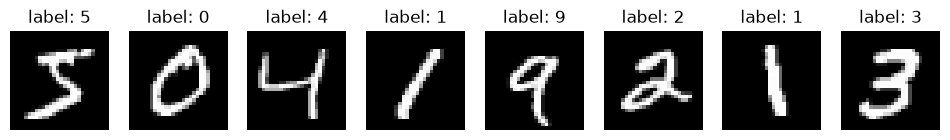

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")   # squeeze: (1,28,28) -> (28,28)
    ax.set_title(f"label: {label}")
    ax.axis("off")
plt.show()

## 2. 모델 정의 (간단한 CNN)

합성곱(Conv) 층이 이미지의 지역적 특징(선, 모서리 등)을 추출하고, 마지막 완전연결(Linear) 층이 10개 숫자 중 하나로 분류합니다.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # 입력: (배치, 1, 28, 28) - 흑백이라 채널 1개
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # -> (32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (32, 14, 14) 크기 절반
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # -> (64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # -> (64, 7, 7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),               # (64, 7, 7) -> 3136짜리 1차원 벡터
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),           # 과적합 방지: 학습 시 뉴런 25% 무작위 비활성화
            nn.Linear(128, 10),         # 최종 출력: 숫자 0~9 각각의 점수
        )

    def forward(self, x):
        """입력 이미지가 모델을 통과하는 경로 정의"""
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)   # 모델을 GPU로! (데이터와 같은 device 필수)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"학습할 파라미터 수: {n_params:,}개")

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
학습할 파라미터 수: 421,642개


## 3. 손실 함수와 옵티마이저

In [5]:
criterion = nn.CrossEntropyLoss()                             # 분류 문제의 표준 손실 함수
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)  # 가장 널리 쓰이는 옵티마이저

## 4. 학습 루프와 평가 함수 정의

In [6]:
def train(epoch):
    model.train()   # 학습 모드 (Dropout 활성화)
    total_loss = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # 데이터를 모델과 같은 device로 이동
        images, labels = images.to(device), labels.to(device)

        # === 딥러닝 학습의 핵심 4줄 ===
        optimizer.zero_grad()              # 1) 기울기 초기화
        outputs = model(images)            #    순전파 (예측)
        loss = criterion(outputs, labels)  # 2) 손실 계산
        loss.backward()                    # 3) 역전파 (기울기 계산)
        optimizer.step()                   # 4) 파라미터 업데이트
        # ==============================

        total_loss += loss.item()
        if (batch_idx + 1) % 100 == 0:
            print(f"  Epoch {epoch} [{(batch_idx + 1) * BATCH_SIZE:>6}/{len(train_dataset)}] "
                  f"loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"  -> Epoch {epoch} 평균 loss: {avg_loss:.4f}")


def evaluate():
    model.eval()    # 평가 모드 (Dropout 비활성화)
    correct = 0

    with torch.no_grad():   # 평가 때는 기울기 계산 불필요 -> 메모리 절약, 속도 향상
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = outputs.argmax(dim=1)   # 10개 점수 중 가장 높은 것 = 예측 숫자
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / len(test_dataset)
    print(f"  -> 테스트 정확도: {accuracy:.2f}% ({correct}/{len(test_dataset)})")
    return accuracy

## 5. 학습 실행

RTX 2060 기준 1~2분 정도 걸립니다. 에폭마다 loss가 줄고 정확도가 오르는 것을 관찰하세요.

In [7]:
start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    print(f"[Epoch {epoch}/{EPOCHS}]")
    train(epoch)
    evaluate()
    print()

elapsed = time.perf_counter() - start
print(f"총 학습 시간: {elapsed:.1f}초")

[Epoch 1/3]
  Epoch 1 [ 12800/60000] loss: 0.1946
  Epoch 1 [ 25600/60000] loss: 0.1659
  Epoch 1 [ 38400/60000] loss: 0.1091
  Epoch 1 [ 51200/60000] loss: 0.0711
  -> Epoch 1 평균 loss: 0.1895
  -> 테스트 정확도: 98.18% (9818/10000)

[Epoch 2/3]
  Epoch 2 [ 12800/60000] loss: 0.0758
  Epoch 2 [ 25600/60000] loss: 0.0366
  Epoch 2 [ 38400/60000] loss: 0.0293
  Epoch 2 [ 51200/60000] loss: 0.0611
  -> Epoch 2 평균 loss: 0.0581
  -> 테스트 정확도: 98.85% (9885/10000)

[Epoch 3/3]
  Epoch 3 [ 12800/60000] loss: 0.0862
  Epoch 3 [ 25600/60000] loss: 0.0412
  Epoch 3 [ 38400/60000] loss: 0.0166
  Epoch 3 [ 51200/60000] loss: 0.0566
  -> Epoch 3 평균 loss: 0.0426
  -> 테스트 정확도: 98.74% (9874/10000)

총 학습 시간: 52.6초


## 6. 모델 저장 → 불러오기 → 예측

실제 서비스에서 쓰는 패턴입니다. 파라미터(`state_dict`)만 저장하는 것이 표준 방식입니다.

In [8]:
# 저장
torch.save(model.state_dict(), "mnist_cnn.pt")
print("모델 저장 완료: mnist_cnn.pt")

# 불러오기
loaded_model = SimpleCNN().to(device)
loaded_model.load_state_dict(torch.load("mnist_cnn.pt", weights_only=True))
loaded_model.eval()

모델 저장 완료: mnist_cnn.pt


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

### 예측 결과를 눈으로 확인

C:\projects\PycharmProjects\JupyterProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\projects\PycharmProjects\JupyterProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\projects\PycharmProjects\JupyterProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\projects\PycharmProjects\JupyterProject\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


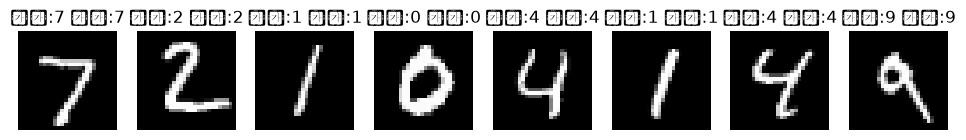

In [9]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
with torch.no_grad():
    for i, ax in enumerate(axes):
        image, label = test_dataset[i]
        output = loaded_model(image.unsqueeze(0).to(device))  # 배치 차원 추가
        pred = output.argmax(dim=1).item()
        ax.imshow(image.squeeze(), cmap="gray")
        color = "black" if pred == label else "red"           # 틀리면 빨간색
        ax.set_title(f"정답:{label} 예측:{pred}", color=color)
        ax.axis("off")
plt.show()

---
**2단계 완료!**

**도전 과제**: `EPOCHS`, `LEARNING_RATE`, 모델 구조(층 추가, 채널 수 변경 등)를 바꿔보며 정확도 변화를 관찰해보세요.